In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [11]:
data = fetch_california_housing()

X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)
df["Price"] = y

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
model_linear = LinearRegression()
model_linear.fit(X_train, y_train)

LinearRegression()

In [14]:
y_train_pred = model_linear.predict(X_train)
y_test_pred = model_linear.predict(X_test)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("LINEAL")
print("MSE Train:", mse_train)
print("MSE Test:", mse_test)
print("R2 Train:", r2_train)
print("R2 Test:", r2_test)

LINEAL
MSE Train: 0.5179331255246699
MSE Test: 0.5558915986952422
R2 Train: 0.6125511913966952
R2 Test: 0.5757877060324524


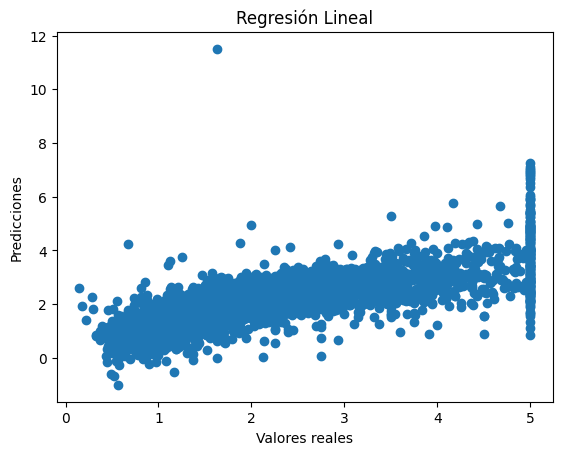

In [15]:
plt.scatter(y_test, y_test_pred)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Regresión Lineal")
plt.show()

In [16]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

LinearRegression()

In [17]:
y_train_pred_poly = model_poly.predict(X_train_poly)
y_test_pred_poly = model_poly.predict(X_test_poly)

mse_train_poly = mean_squared_error(y_train, y_train_pred_poly)
mse_test_poly = mean_squared_error(y_test, y_test_pred_poly)

r2_train_poly = r2_score(y_train, y_train_pred_poly)
r2_test_poly = r2_score(y_test, y_test_pred_poly)

print("\nPOLINÓMICO")
print("MSE Train:", mse_train_poly)
print("MSE Test:", mse_test_poly)
print("R2 Train:", r2_train_poly)
print("R2 Test:", r2_test_poly)


POLINÓMICO
MSE Train: 0.4207266151573583
MSE Test: 0.4643015261571134
R2 Train: 0.6852681982344935
R2 Test: 0.6456819711504156


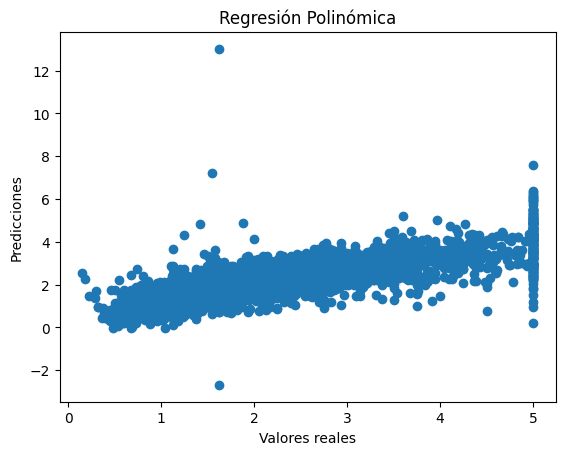

In [18]:
plt.scatter(y_test, y_test_pred_poly)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Regresión Polinómica")
plt.show()

En este trabajo comparamos un modelo de regresión lineal con uno polinómico de grado 2 para predecir el precio de viviendas. El modelo que resultó mejor fue el que tuvo menor error (MSE) y mayor valor de R² en los datos de test, ya que eso indica que funciona mejor con datos nuevos. En nuestro caso, el modelo polinómico mejoró bastante en el conjunto de entrenamiento, pero en el de test no mejoró tanto o incluso empeoró, lo que muestra que hay overfitting. Esto significa que el modelo se ajusta demasiado a los datos de entrenamiento y después no predice tan bien cuando aparecen datos nuevos. Se puede ver porque el R² en train es mucho más alto que en test y el error en test es mayor. Por otro lado, para saber qué variable tiene más impacto en el precio analizamos los coeficientes del modelo lineal, y vimos que la variable con el coeficiente más grande en valor absoluto es la que más influye en el precio de las casas, lo que ayuda a entender mejor qué factores afectan el valor de las viviendas.